<a href="https://colab.research.google.com/github/rajiv-ramteke/Time-Series-Demand-project/blob/main/Time_Series_Demand_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit prophet plotly pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import joblib

In [ ]:
df = pd.read_csv("/content/Walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
print(df.columns)

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [ ]:
forecast_df = df[['Date', 'Weekly_Sales']]

forecast_df.columns = ['ds', 'y']

forecast_df.head()

,ds,y
0,2010-02-05,1643690.90
1,2010-02-12,1641957.44
2,2010-02-19,1611968.17
3,2010-02-26,1409727.59
4,2010-03-05,1554806.68


In [ ]:
model = Prophet()

In [ ]:
model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=90)

In [ ]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,1.054178e+06,340125.499385,1.716310e+06,1.054178e+06,1.054178e+06,14921.141389,14921.141389,14921.141389,14921.141389,14921.141389,14921.141389,0.0,0.0,0.0,1.069099e+06
1,2010-02-12,1.053862e+06,301518.869404,1.770845e+06,1.053862e+06,1.053862e+06,29892.791129,29892.791129,29892.791129,29892.791129,29892.791129,29892.791129,0.0,0.0,0.0,1.083755e+06
2,2010-02-19,1.053547e+06,314553.850753,1.718884e+06,1.053547e+06,1.053547e+06,-902.814272,-902.814272,-902.814272,-902.814272,-902.814272,-902.814272,0.0,0.0,0.0,1.052644e+06
3,2010-02-26,1.053231e+06,329185.497302,1.713589e+06,1.053231e+06,1.053231e+06,-27582.906263,-27582.906263,-27582.906263,-27582.906263,-27582.906263,-27582.906263,0.0,0.0,0.0,1.025648e+06
4,2010-03-05,1.052915e+06,306644.993963,1.769565e+06,1.052915e+06,1.052915e+06,-33397.081794,-33397.081794,-33397.081794,-33397.081794,-33397.081794,-33397.081794,0.0,0.0,0.0,1.019518e+06


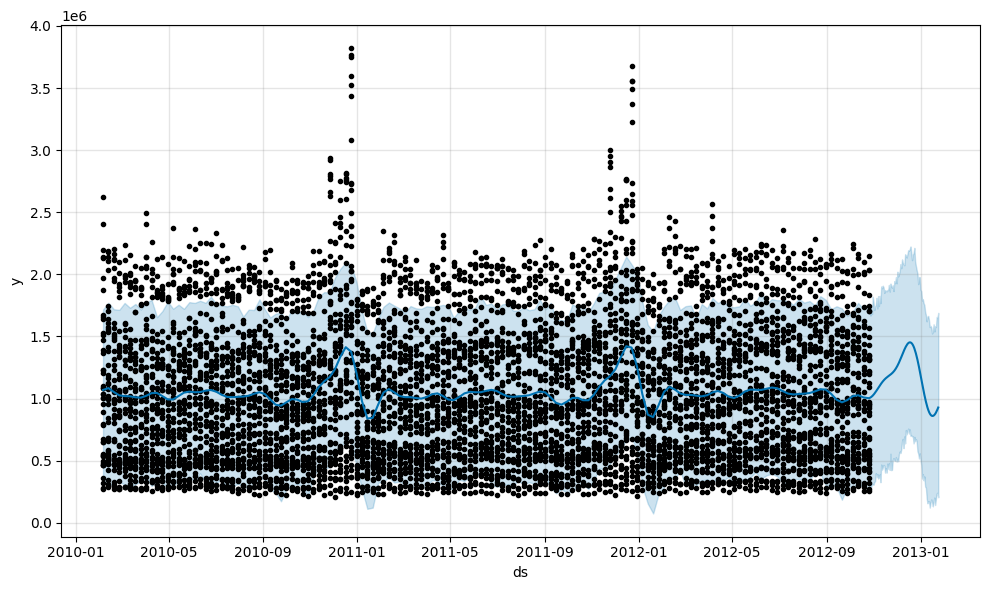

In [ ]:
model.plot(forecast)
plt.show()

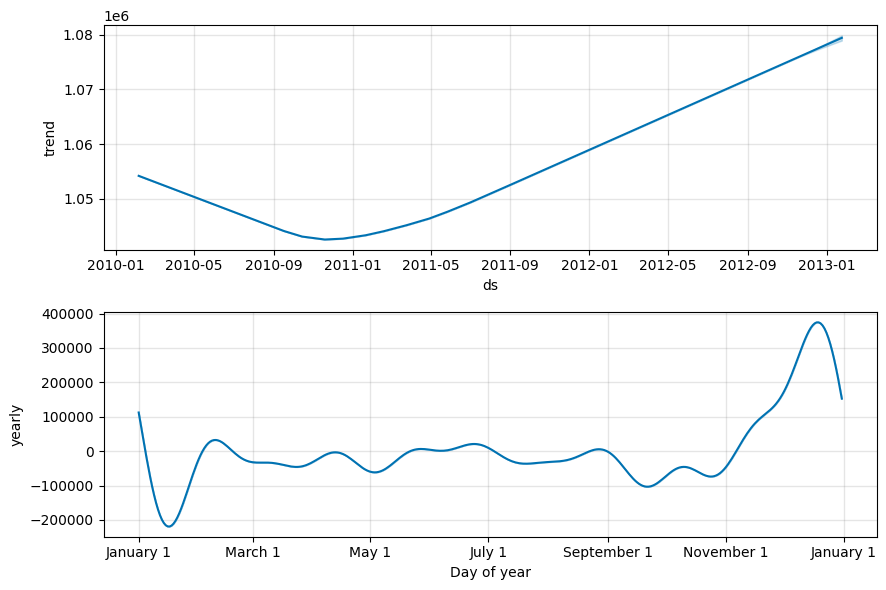

In [ ]:
model.plot_components(forecast)
plt.show()

In [ ]:
joblib.dump(model, "walmart_demand_model.pkl")

['walmart_demand_model.pkl']

In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib
from prophet.plot import plot_plotly

st.set_page_config(page_title="Walmart Demand Forecast", layout="wide")

st.title("Walmart Demand Forecast Dashboard")

# Load model
model = joblib.load("walmart_demand_model.pkl")

# Load dataset
df = pd.read_csv("Walmart.csv")

df['Date'] = pd.to_datetime(df['Date'])

forecast_df = df[['Date', 'Weekly_Sales']]
forecast_df.columns = ['ds', 'y']

# Sidebar
st.sidebar.header("Forecast Settings")

days = st.sidebar.slider(
    "Select Forecast Days",
    7,
    365,
    90
)

# Future dataframe
future = model.make_future_dataframe(periods=days)

# Prediction
forecast = model.predict(future)

# KPI
st.subheader("Current Statistics")

col1, col2, col3 = st.columns(3)

col1.metric("Total Sales", f"${df['Weekly_Sales'].sum():,.0f}")

col2.metric("Average Sales", f"${df['Weekly_Sales'].mean():,.0f}")

col3.metric("Maximum Sales", f"${df['Weekly_Sales'].max():,.0f}")

# Forecast Chart
st.subheader("Demand Forecast")

fig1 = plot_plotly(model, forecast)

st.plotly_chart(fig1, use_container_width=True)

# Sales Trend
st.subheader("Weekly Sales Trend")

st.line_chart(df['Weekly_Sales'])

# Demand Distribution
st.subheader("Demand Distribution")

st.bar_chart(df['Weekly_Sales'])

# Forecast Table
st.subheader("Forecast Data")

st.write(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(days)
)

# Raw Data
if st.checkbox("Show Raw Dataset"):
    st.write(df)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully")

app.py created successfully


In [ ]:
requirements = '''
streamlit
pandas
numpy
matplotlib
plotly
prophet
joblib
'''

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [ ]:
readme = '''
# Walmart Demand Forecast Dashboard

Time Series Forecasting project using Walmart sales dataset.

Features:
- Demand Forecasting
- Sales Trend Analysis
- Demand Distribution
- Interactive Dashboard

Technologies:
- Python
- Prophet
- Streamlit
- Plotly
'''

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created")

README.md created


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)